# 單一職責原則 (SRP)

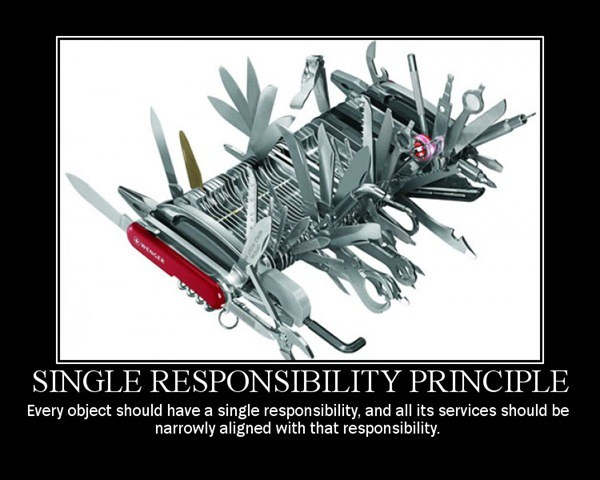


## 定義
每個模塊或類別應只有一個變更的原因。也就是說，類別應專注於完成一項職責。

## 判斷導入時機
- Do：
當你的類別或函數負責多個業務邏輯，導致修改代碼時影響範圍太大。
當需要將不同職責清晰分離以增強可測試性。

- Don't：
當拆分類別會引入不必要的複雜度或多餘的依賴關係。

----

## 完整案例

### 需求情境

假設我們正在開發一個用於處理客戶訂單的系統。最初，我們設計了一個 Order 類別，負責管理訂單詳情、計算總金額，以及將訂單保存到資料庫。 <br>
開發一個簡單的訂單處理系統，其中包括以下功能：

1. 訂單項目記錄
2. 計算訂單總金額
3. 將訂單保存到資料庫

### 初始設計
問題：Order 類別負責處理業務邏輯（計算總金額）和資料持久化（保存到資料庫），違反了 SRP，可能導致修改一個功能時影響另一個功能。

In [7]:
class Item:
    def __init__(self, name, price):
        self.name = name
        self.price = price

class Order:
    def __init__(self, items):
        self.items = items

    def calculate_total(self):
        return sum(item.price for item in self.items)

    def save_to_db(self):
        print(f"Saving order to database with total: {self.calculate_total()}")

# 模擬使用
items = [
    Item(name="Laptop", price=1500),
    Item(name="Mouse", price=50),
    Item(name="Keyboard", price=100)
]

order = Order(items)
print(f"Order Total: {order.calculate_total()}")  # 計算總金額
order.save_to_db()  # 保存到資料庫


Order Total: 1650
Saving order to database with total: 1650


> 問題分析

1. 職責過多：Order 同時負責兩件事：
    - 計算總金額
    - 保存到資料庫

2. 潛在問題：如果需要修改資料保存邏輯（例如改成保存到雲端），就會導致與業務邏輯相關的代碼也可能被意外影響。

### 重構設計
解決方案：將資料持久化邏輯從 Order 類別中分離出來，交由專門的 OrderRepository 類別處理。

In [8]:
class Item:
    def __init__(self, name, price):
        self.name = name
        self.price = price

class Order:
    def __init__(self, items):
        self.items = items

    def calculate_total(self):
        return sum(item.price for item in self.items)

class OrderRepository:
    def save(self, order):
        print(f"Saving order to database with total: {order.calculate_total()}")

# 模擬使用
items = [
    Item(name="Laptop", price=1500),
    Item(name="Mouse", price=50),
    Item(name="Keyboard", price=100)
]

order = Order(items)
print(f"Order Total: {order.calculate_total()}")  # 計算總金額

# 使用 OrderRepository 保存訂單
repository = OrderRepository()
repository.save(order)


Order Total: 1650
Saving order to database with total: 1650


### 模擬資料庫 擴展設計
進一步擴展，加入模擬資料庫儲存的邏輯，讓系統更加貼近實際應用場景。

In [11]:
class Database:
    def __init__(self):
        self.data = []

    def insert(self, record):
        self.data.append(record)
        print(f"Record inserted: {record}")

class OrderRepository:
    def __init__(self, database):
        self.database = database

    def save(self, order):
        record = {"items": [item.name for item in order.items], "total": order.calculate_total()}
        self.database.insert(record)

# 模擬使用
db = Database()
repository = OrderRepository(db)

items = [
    Item(name="Laptop", price=1500),
    Item(name="Mouse", price=50),
    Item(name="Keyboard", price=100)
]

order = Order(items)
print(f"Order Total: {order.calculate_total()}")  # 計算總金額
repository.save(order)  # 保存訂單


Order Total: 1650
Record inserted: {'items': ['Laptop', 'Mouse', 'Keyboard'], 'total': 1650}


### 重構優點
- 高可維護性：業務邏輯和資料持久化邏輯分離，變更不會互相影響。
- 高可測試性：Order 類別可以獨立測試業務邏輯，而 OrderRepository 可以專注於測試資料保存邏輯。
- 高可擴展性：將資料持久化邏輯抽象到 OrderRepository，可以輕鬆替換資料庫（例如從假資料庫切換到真實資料庫）。